In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully


In [13]:
base = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '02_data_cleaning_pipeline'
)

clean_path = os.path.join(base, 'data', 'processed', 'loans_clean.csv')
df = pd.read_csv(clean_path)

print(f'Clean data loaded')
print(f'Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumns:')
for col in df.columns:
    print(f'  {col:<30} {df[col].dtype}')

Clean data loaded
Shape  : 2,260,668 rows x 36 columns

Columns:
  loan_amnt                      float64
  funded_amnt                    float64
  term                           int64
  int_rate                       float64
  installment                    float64
  grade                          object
  sub_grade                      object
  emp_length                     float64
  home_ownership                 object
  annual_inc                     float64
  verification_status            object
  issue_d                        object
  loan_status                    object
  purpose                        object
  addr_state                     object
  dti                            float64
  delinq_2yrs                    float64
  earliest_cr_line               object
  open_acc                       float64
  pub_rec                        float64
  revol_bal                      float64
  revol_util                     float64
  total_acc                      float64
  i

In [14]:
# Recreate is_default if it was not saved in loans_clean.csv
if 'is_default' not in df.columns:
    if 'loan_status_simple' in df.columns:
        df['is_default'] = (df['loan_status_simple'] == 'Bad').astype(int)
        print('is_default recreated from loan_status_simple')
    elif 'loan_status' in df.columns:
        bad_statuses = ['Charged Off', 'Default',
                        'Late (31-120 Days)', 'Late (16-30 Days)']
        df['is_default'] = df['loan_status'].isin(bad_statuses).astype(int)
        print('is_default recreated from loan_status')
    print(f'Default rate: {df["is_default"].mean()*100:.2f}%')
else:
    print(f'is_default exists - Default rate: {df["is_default"].mean()*100:.2f}%')

is_default recreated from loan_status_simple
Default rate: 12.86%


In [15]:
# Feature 1 — Debt to Income Band (more granular than notebook 2)
# DTI is one of the strongest predictors of default
# Low DTI = borrower has capacity to repay
# High DTI = borrower is stretched thin

if 'dti' in df.columns:
    df['dti_risk'] = pd.cut(
        df['dti'],
        bins  =[0, 10, 15, 20, 25, 30, 999],
        labels=['Very Low', 'Low', 'Moderate', 'Elevated', 'High', 'Very High']
    ).astype(str)
    print('dti_risk created')
    print(df['dti_risk'].value_counts().to_string())

dti_risk created
dti_risk
Moderate     476959
Low          447418
Very Low     408636
Elevated     398968
High         283289
Very High    245398


In [16]:
# Feature 2 — Annual Income Band
# Segments borrowers by income level
# Used in dashboard to show risk profile by income segment

if 'annual_inc' in df.columns:
    df['income_band'] = pd.cut(
        df['annual_inc'],
        bins  =[0, 30000, 50000, 75000, 100000, 150000, 999999999],
        labels=['<30K', '30-50K', '50-75K', '75-100K', '100-150K', '>150K']
    ).astype(str)
    print('income_band created')
    print(df['income_band'].value_counts().to_string())

income_band created
income_band
50-75K      678683
30-50K      543851
75-100K     420175
100-150K    313173
<30K        170806
>150K       133980


In [17]:
# Feature 3 — Revolving Utilisation Risk Flag
# High revolving utilisation (using most of available credit)
# is a strong signal of financial stress

if 'revol_util' in df.columns:
    df['revol_util_band'] = pd.cut(
        df['revol_util'],
        bins  =[0, 20, 40, 60, 80, 100],
        labels=['<20%', '20-40%', '40-60%', '60-80%', '>80%']
    ).astype(str)

    # Flag high utilisation
    df['high_revol_util'] = (df['revol_util'] > 80).astype(int)
    print('revol_util_band and high_revol_util created')
    print(f'High utilisation rate: {df["high_revol_util"].mean()*100:.1f}%')

revol_util_band and high_revol_util created
High utilisation rate: 13.6%


In [18]:
# Feature 4 — Employment Stability Flag
# Borrowers with longer employment tend to be more stable
# Used as a risk indicator in the dashboard

if 'emp_length' in df.columns:
    df['emp_stability'] = pd.cut(
        df['emp_length'],
        bins  =[-1, 1, 3, 6, 10, 100],
        labels=['<1 Year', '1-3 Years', '3-6 Years', '6-10 Years', '10+ Years']
    ).astype(str)
    print('emp_stability created')
    print(df['emp_stability'].value_counts().to_string())

emp_stability created
emp_stability
6-10 Years    1012009
3-6 Years      525838
1-3 Years      384430
<1 Year        338391


In [19]:
# Feature 5 — Loan Purpose Group
# Lending Club has many specific purposes
# We group them into broader categories for cleaner dashboard visuals

if 'purpose' in df.columns:
    purpose_map = {
        'Debt Consolidation'  : 'Debt Consolidation',
        'Credit Card'         : 'Debt Consolidation',
        'Home Improvement'    : 'Home',
        'House'               : 'Home',
        'Moving'              : 'Home',
        'Car'                 : 'Vehicle',
        'Major Purchase'      : 'Major Purchase',
        'Medical'             : 'Personal',
        'Vacation'            : 'Personal',
        'Wedding'             : 'Personal',
        'Small Business'      : 'Business',
        'Educational'         : 'Education',
        'Renewable Energy'    : 'Other'
    }
    df['purpose_group'] = df['purpose'].map(purpose_map).fillna('Other')
    print('purpose_group created')
    print(df['purpose_group'].value_counts().to_string())

purpose_group created
purpose_group
Debt Consolidation    1794848
Home                   179996
Other                  140885
Major Purchase          50445
Personal                45368
Business                24689
Vehicle                 24013
Education                 424


In [20]:
# Feature 6 — Vintage (Year of Issue)
# Vintage analysis tracks how loans issued in each year performed
# A key tool in credit portfolio management
# Loans from same vintage share similar economic conditions

if 'issue_year' in df.columns:
    df['vintage'] = 'VTG_' + df['issue_year'].astype(str)
    print('vintage created')
    print(df['vintage'].value_counts().sort_index().to_string())

vintage created
vintage
VTG_2007       603
VTG_2008      2393
VTG_2009      5281
VTG_2010     12537
VTG_2011     21721
VTG_2012     53367
VTG_2013    134814
VTG_2014    235629
VTG_2015    421095
VTG_2016    434407
VTG_2017    443579
VTG_2018    495242


In [21]:
# Feature 7 — Delinquency Flag
# Any past delinquency is a strong default predictor

if 'delinq_2yrs' in df.columns:
    df['ever_delinquent'] = (df['delinq_2yrs'] > 0).astype(int)
    print('ever_delinquent created')
    print(f'Ever delinquent rate: {df["ever_delinquent"].mean()*100:.1f}%')

# Feature 8 — Public Record Flag
if 'pub_rec' in df.columns:
    df['has_pub_rec'] = (df['pub_rec'] > 0).astype(int)
    print('has_pub_rec created')
    print(f'Has public record rate: {df["has_pub_rec"].mean()*100:.1f}%')

ever_delinquent created
Ever delinquent rate: 18.6%
has_pub_rec created
Has public record rate: 15.8%


In [22]:
# Check what columns we have
print('Columns in df:')
print(list(df.columns))
print()
print('Does is_default exist:', 'is_default' in df.columns)
print('Does loan_status_simple exist:', 'loan_status_simple' in df.columns)

Columns in df:
['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'issue_year', 'issue_month', 'issue_month_name', 'issue_quarter', 'credit_history_years', 'loan_status_simple', 'risk_tier', 'loan_size_band', 'int_rate_band', 'dti_band', 'income_band', 'is_bad', 'payment_to_income', 'is_default', 'dti_risk', 'revol_util_band', 'high_revol_util', 'emp_stability', 'purpose_group', 'vintage', 'ever_delinquent', 'has_pub_rec']

Does is_default exist: True
Does loan_status_simple exist: True


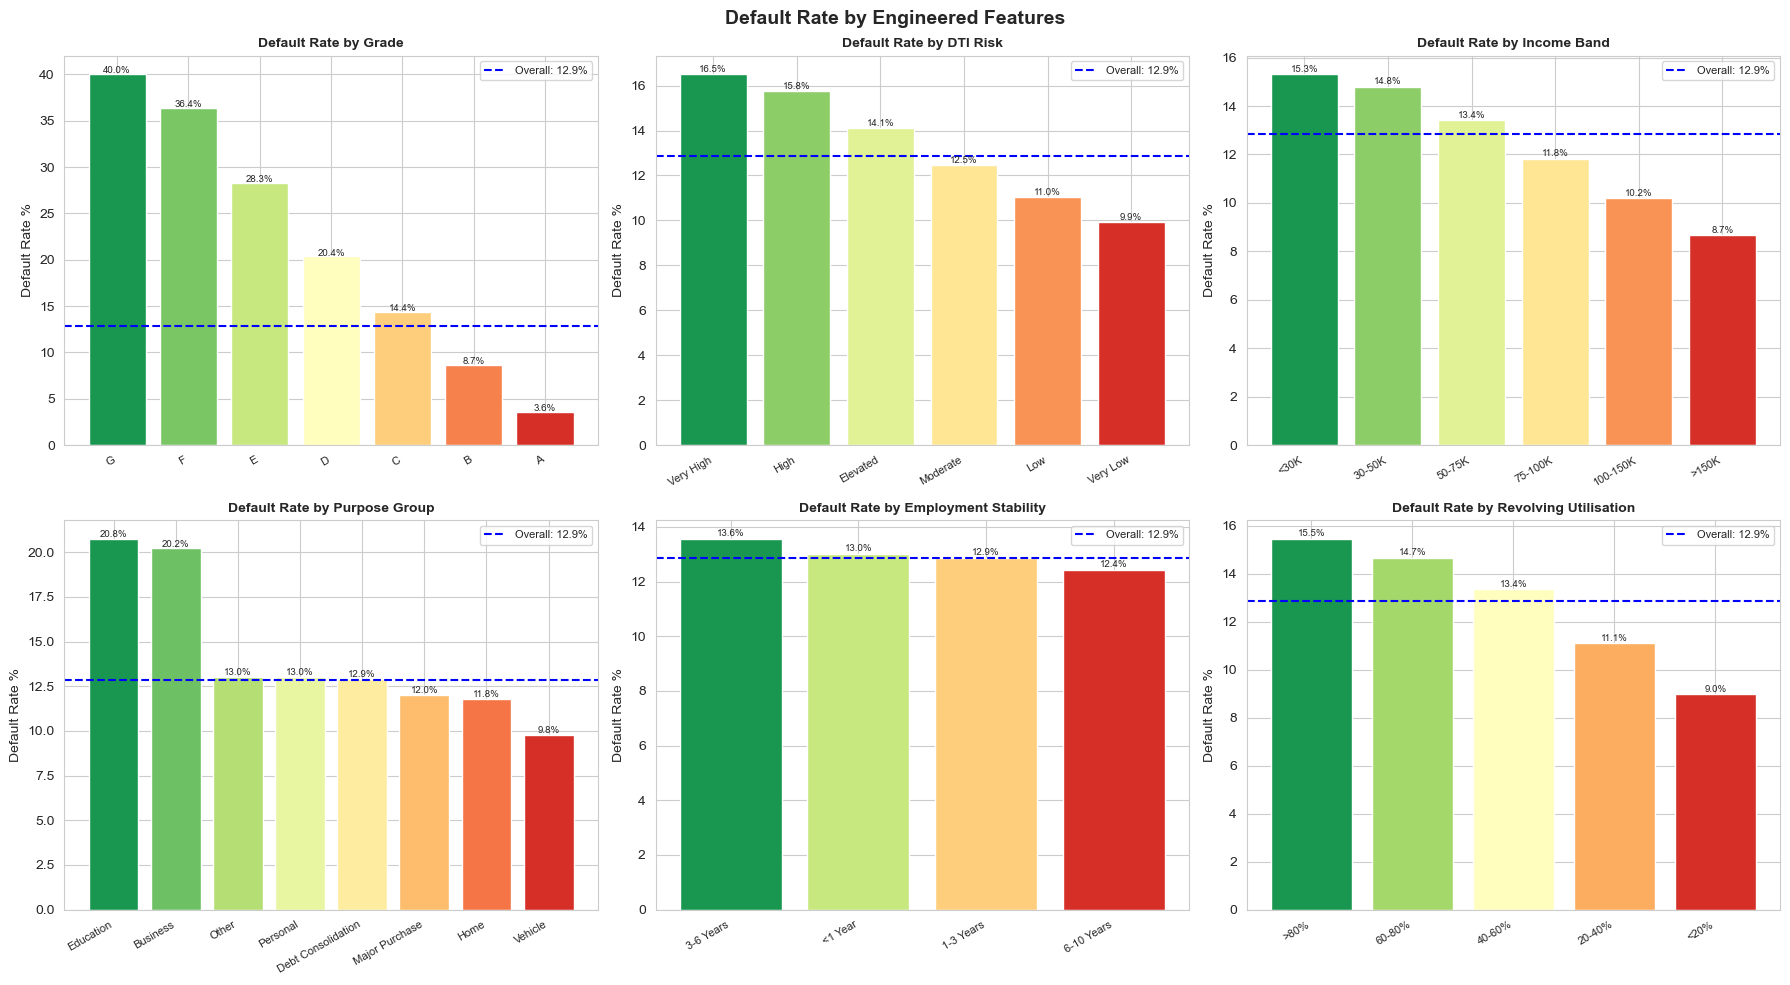

Chart saved


In [23]:
# Default rate by key engineered features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_features = [
    ('grade',           'Default Rate by Grade'),
    ('dti_risk',        'Default Rate by DTI Risk'),
    ('income_band',     'Default Rate by Income Band'),
    ('purpose_group',   'Default Rate by Purpose Group'),
    ('emp_stability',   'Default Rate by Employment Stability'),
    ('revol_util_band', 'Default Rate by Revolving Utilisation')
]
plot_features = [(f, t) for f, t in plot_features if f in df.columns]

for i, (feat, title) in enumerate(plot_features):
    dr = df.groupby(feat)['is_default'].mean() * 100
    dr = dr.sort_values(ascending=False)

    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(dr)))
    bars = axes[i].bar(range(len(dr)), dr.values, color=colors, edgecolor='white')
    axes[i].set_xticks(range(len(dr)))
    axes[i].set_xticklabels(dr.index, rotation=30, ha='right', fontsize=8)
    axes[i].axhline(y=df['is_default'].mean()*100,
                    color='blue', linestyle='--', linewidth=1.5,
                    label=f'Overall: {df["is_default"].mean()*100:.1f}%')
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Default Rate %')
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, dr.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', fontsize=7)

plt.suptitle('Default Rate by Engineered Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '06_default_by_features.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [24]:
if 'addr_state' in df.columns:
    state_summary = df.groupby('addr_state').agg(
        Total_Loans      =('loan_amnt',   'count'),
        Total_Volume     =('loan_amnt',   'sum'),
        Avg_Loan_Amt     =('loan_amnt',   'mean'),
        Avg_Int_Rate     =('int_rate',    'mean'),
        Avg_DTI          =('dti',         'mean'),
        Default_Rate     =('is_default',  'mean'),
        Total_Defaults   =('is_default',  'sum'),
        Avg_Annual_Inc   =('annual_inc',  'mean')
    ).reset_index()

    state_summary = state_summary.round(2)
    state_summary['Default_Rate_%'] = (state_summary['Default_Rate'] * 100).round(2)
    state_summary['Total_Volume_M']  = (state_summary['Total_Volume'] / 1e6).round(2)

    # Sort by total loans
    state_summary = state_summary.sort_values('Total_Loans', ascending=False)

    print('STATE LEVEL SUMMARY')
    print('='*80)
    print(state_summary[['addr_state','Total_Loans','Total_Volume_M',
                          'Avg_Int_Rate','Default_Rate_%']].head(15).to_string(index=False))
    print(f'\nTotal states: {len(state_summary)}')

STATE LEVEL SUMMARY
addr_state  Total_Loans  Total_Volume_M  Avg_Int_Rate  Default_Rate_%
        CA       314533       4808.4800       12.9800         13.0000
        NY       186389       2767.1600       13.2600         14.0000
        TX       186335       2931.1300       13.0000         13.0000
        FL       161991       2333.0300       13.1600         14.0000
        IL        91173       1410.4500       12.9600         11.0000
        NJ        83132       1316.2100       12.9900         13.0000
        PA        76939       1131.9900       13.1500         13.0000
        OH        75132       1077.1400       13.1400         13.0000
        GA        74196       1136.7900       13.2100         12.0000
        VA        62954       1013.0200       13.1100         13.0000
        NC        62730        930.4400       13.1900         14.0000
        MI        58770        841.6500       13.1600         13.0000
        MD        54008        856.8800       13.2400         13.0000


In [25]:
# Top and bottom states by default rate
print('TOP 10 STATES - HIGHEST DEFAULT RATE')
print('='*50)
top_default = state_summary.nlargest(10, 'Default_Rate_%')
print(top_default[['addr_state','Total_Loans','Default_Rate_%']].to_string(index=False))

print('\nTOP 10 STATES - LOWEST DEFAULT RATE')
print('='*50)
low_default = state_summary[state_summary['Total_Loans'] > 100].nsmallest(10, 'Default_Rate_%')
print(low_default[['addr_state','Total_Loans','Default_Rate_%']].to_string(index=False))

TOP 10 STATES - HIGHEST DEFAULT RATE
addr_state  Total_Loans  Default_Rate_%
        IA           14         21.0000
        AL        27284         16.0000
        NV        32657         15.0000
        LA        25759         15.0000
        OK        20691         15.0000
        AR        17074         15.0000
        MS        12639         15.0000
        NY       186389         14.0000
        FL       161991         14.0000
        NC        62730         14.0000

TOP 10 STATES - LOWEST DEFAULT RATE
addr_state  Total_Loans  Default_Rate_%
        ME         4974          6.0000
        VT         4937          8.0000
        ID         4308          8.0000
        NH        11142          9.0000
        DC         5356          9.0000
        CO        48183         10.0000
        SC        28003         10.0000
        OR        26789         10.0000
        WV         8351         10.0000
        ND         3591         10.0000


In [26]:
if 'issue_year' in df.columns and 'issue_month' in df.columns:

    # Monthly summary
    time_summary = df.groupby(['issue_year', 'issue_month']).agg(
        Loan_Count   =('loan_amnt',  'count'),
        Total_Volume =('loan_amnt',  'sum'),
        Avg_Loan_Amt =('loan_amnt',  'mean'),
        Avg_Int_Rate =('int_rate',   'mean'),
        Default_Rate =('is_default', 'mean'),
        Avg_DTI      =('dti',        'mean')
    ).reset_index()

    time_summary = time_summary.sort_values(['issue_year', 'issue_month'])
    time_summary['Default_Rate_%'] = (time_summary['Default_Rate'] * 100).round(2)
    time_summary['Total_Volume_M']  = (time_summary['Total_Volume'] / 1e6).round(3)

    # Create a date label for Power BI
    time_summary['Year_Month'] = (
        time_summary['issue_year'].astype(str) + '-' +
        time_summary['issue_month'].astype(str).str.zfill(2)
    )

    print('TIME TREND SUMMARY (Monthly)')
    print('='*65)
    print(time_summary[['Year_Month','Loan_Count',
                         'Total_Volume_M','Avg_Int_Rate',
                         'Default_Rate_%']].tail(24).to_string(index=False))
    print(f'\nTotal months: {len(time_summary)}')

TIME TREND SUMMARY (Monthly)
Year_Month  Loan_Count  Total_Volume_M  Avg_Int_Rate  Default_Rate_%
   2017-01       31835        470.4010       13.5649         13.2200
   2017-02       27763        417.3310       13.3892         12.8000
   2017-03       37181        550.2370       13.1831         11.9600
   2017-04       29683        437.9310       13.2997         12.1000
   2017-05       37681        549.5190       13.2929         11.9800
   2017-06       38087        550.9830       13.2635         11.2000
   2017-07       39415        569.3940       13.4303         11.0300
   2017-08       43573        620.4090       13.2352         10.0200
   2017-09       39713        601.3980       13.7608         10.5600
   2017-10       38151        577.8220       13.2115          8.9600
   2017-11       42343        645.5430       12.7767          7.8400
   2017-12       38154        593.9900       12.6518          7.7200
   2018-01       36347        584.2750       12.3857          6.4300
   20

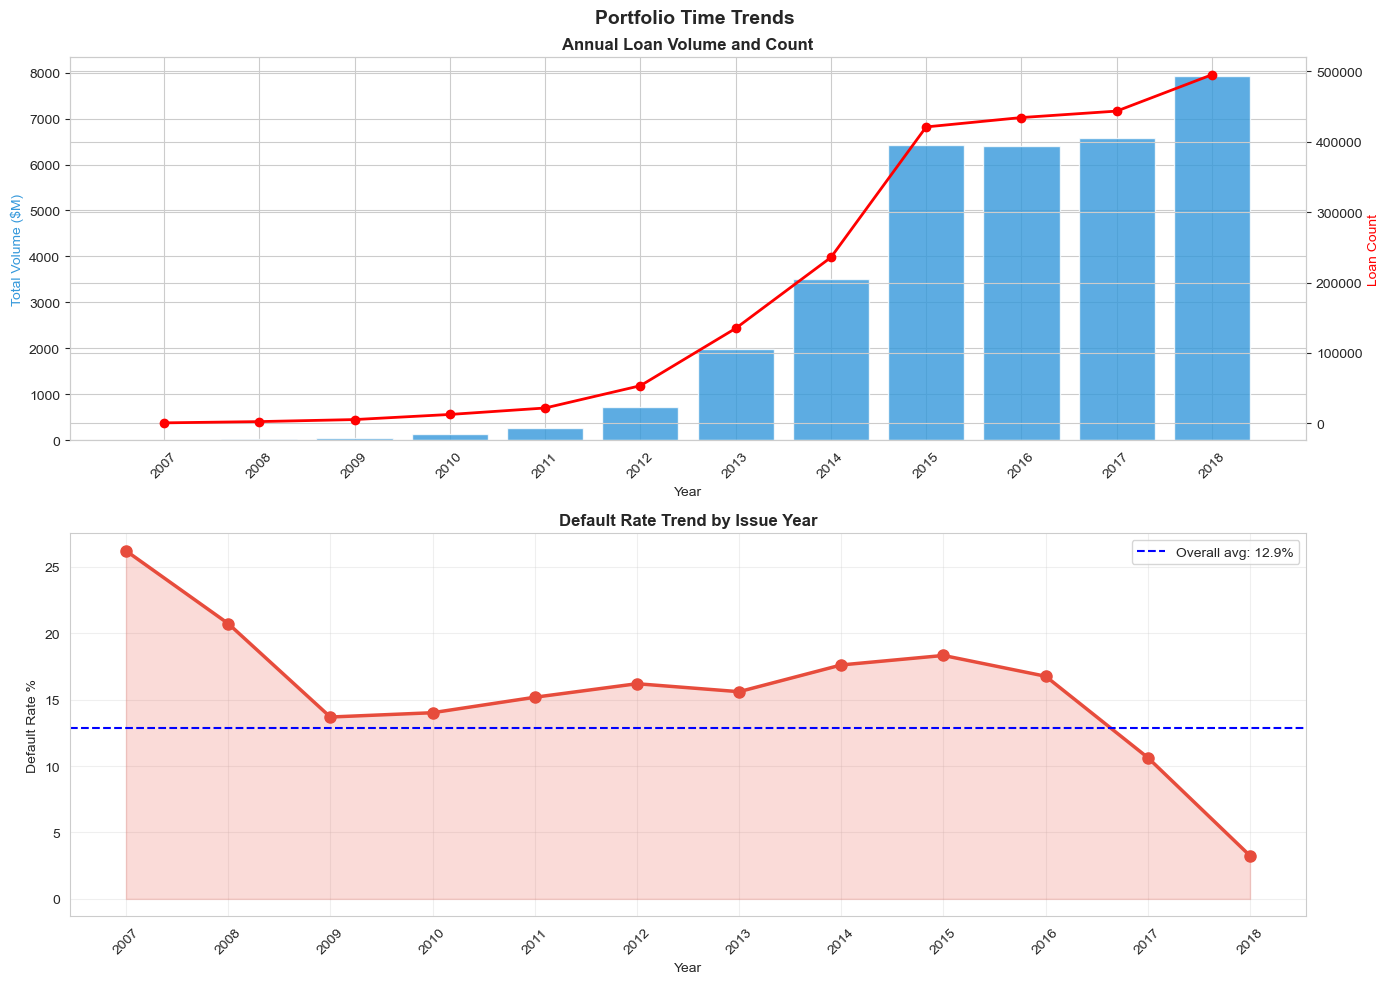

Time trend chart saved


In [27]:
# Time trend charts
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Annual loan volume
annual = df.groupby('issue_year').agg(
    Loan_Count  =('loan_amnt', 'count'),
    Total_Volume=('loan_amnt', 'sum')
).reset_index()

axes[0].bar(annual['issue_year'].astype(str),
            annual['Total_Volume'] / 1e6,
            color='#3498db', edgecolor='white', alpha=0.8)
ax2 = axes[0].twinx()
ax2.plot(range(len(annual)), annual['Loan_Count'],
         'ro-', linewidth=2, markersize=6, label='Loan Count')
axes[0].set_title('Annual Loan Volume and Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Volume ($M)', color='#3498db')
ax2.set_ylabel('Loan Count', color='red')
axes[0].tick_params(axis='x', rotation=45)

# Annual default rate trend
annual_dr = df.groupby('issue_year')['is_default'].mean() * 100
axes[1].plot(annual_dr.index.astype(str), annual_dr.values,
             'o-', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(annual_dr)), annual_dr.values,
                     alpha=0.2, color='#e74c3c')
axes[1].axhline(y=df['is_default'].mean()*100,
                color='blue', linestyle='--', linewidth=1.5,
                label=f'Overall avg: {df["is_default"].mean()*100:.1f}%')
axes[1].set_title('Default Rate Trend by Issue Year',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Default Rate %')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Portfolio Time Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '07_time_trends.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Time trend chart saved')

In [28]:
# Grade level summary
grade_summary = df.groupby('grade').agg(
    Loan_Count    =('loan_amnt',  'count'),
    Total_Volume  =('loan_amnt',  'sum'),
    Avg_Loan_Amt  =('loan_amnt',  'mean'),
    Avg_Int_Rate  =('int_rate',   'mean'),
    Default_Rate  =('is_default', 'mean'),
    Avg_DTI       =('dti',        'mean'),
    Avg_Income    =('annual_inc', 'mean')
).reset_index().sort_values('grade')

grade_summary['Default_Rate_%'] = (grade_summary['Default_Rate'] * 100).round(2)
grade_summary['Volume_%']        = (
    grade_summary['Loan_Count'] / grade_summary['Loan_Count'].sum() * 100
).round(1)

print('GRADE LEVEL SUMMARY')
print('='*70)
print(grade_summary[['grade','Loan_Count','Volume_%',
                      'Avg_Int_Rate','Default_Rate_%','Avg_DTI']].to_string(index=False))

GRADE LEVEL SUMMARY
grade  Loan_Count  Volume_%  Avg_Int_Rate  Default_Rate_%  Avg_DTI
    A      433027   19.2000        7.0845          3.5900  16.0131
    B      663557   29.4000       10.6758          8.6600  17.6726
    C      650053   28.8000       14.1437         14.3600  19.1721
    D      324424   14.4000       18.1431         20.3500  20.4820
    E      135639    6.0000       21.8297         28.2800  21.1147
    F       41800    1.8000       25.4541         36.4200  21.3178
    G       12168    0.5000       28.0743         40.0100  21.6693


In [29]:
# Purpose level summary
purpose_summary = df.groupby('purpose_group').agg(
    Loan_Count  =('loan_amnt',  'count'),
    Total_Volume=('loan_amnt',  'sum'),
    Avg_Loan_Amt=('loan_amnt',  'mean'),
    Avg_Int_Rate=('int_rate',   'mean'),
    Default_Rate=('is_default', 'mean')
).reset_index().sort_values('Loan_Count', ascending=False)

purpose_summary['Default_Rate_%'] = (purpose_summary['Default_Rate'] * 100).round(2)
purpose_summary['Volume_M']        = (purpose_summary['Total_Volume'] / 1e6).round(2)

print('PURPOSE GROUP SUMMARY')
print('='*65)
print(purpose_summary[['purpose_group','Loan_Count','Volume_M',
                         'Avg_Int_Rate','Default_Rate_%']].to_string(index=False))

PURPOSE GROUP SUMMARY
     purpose_group  Loan_Count   Volume_M  Avg_Int_Rate  Default_Rate_%
Debt Consolidation     1794848 28323.3300       12.9970         12.9200
              Home      179996  2557.8600       12.9417         11.7800
             Other      140885  1477.0300       14.2404         13.0200
    Major Purchase       50445   639.7700       12.7637         12.0200
          Personal       45368   383.8100       13.5972         13.0100
          Business       24689   405.9500       15.2637         20.2200
           Vehicle       24013   225.5700       12.1821          9.7800
         Education         424     2.8000       12.1421         20.7500


In [30]:
print('FINAL DATA QUALITY CHECK')
print('='*55)

print(f'Total rows          : {len(df):,}')
print(f'Total columns       : {df.shape[1]}')
print(f'Missing values      : {df.isnull().sum().sum()}')
print(f'Duplicate rows      : {df.duplicated().sum()}')
print(f'Default rate        : {df["is_default"].mean()*100:.2f}%')
print(f'Unique states       : {df["addr_state"].nunique()}')
print(f'Unique grades       : {df["grade"].nunique()}')
print(f'Year range          : {df["issue_year"].min():.0f} - {df["issue_year"].max():.0f}')
print(f'Avg loan amount     : ${df["loan_amnt"].mean():,.0f}')
print(f'Avg interest rate   : {df["int_rate"].mean():.2f}%')
print()

# List all final columns
print('ALL COLUMNS IN FINAL DATASET')
print('='*55)
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col:<30} {df[col].dtype}')

FINAL DATA QUALITY CHECK
Total rows          : 2,260,668
Total columns       : 45
Missing values      : 29
Duplicate rows      : 0
Default rate        : 12.86%
Unique states       : 51
Unique grades       : 7
Year range          : 2007 - 2018
Avg loan amount     : $15,047
Avg interest rate   : 13.09%

ALL COLUMNS IN FINAL DATASET
   1. loan_amnt                      float64
   2. funded_amnt                    float64
   3. term                           int64
   4. int_rate                       float64
   5. installment                    float64
   6. grade                          object
   7. sub_grade                      object
   8. emp_length                     float64
   9. home_ownership                 object
  10. annual_inc                     float64
  11. verification_status            object
  12. issue_d                        object
  13. loan_status                    object
  14. purpose                        object
  15. addr_state                     object
  1

In [31]:
processed_folder = os.path.join(base, 'data', 'processed')

# Convert any remaining category columns to string
for col in df.select_dtypes(include='category').columns:
    df[col] = df[col].astype(str)

# 1 - Main dashboard file
main_path = os.path.join(processed_folder, 'loans_final.csv')
df.to_csv(main_path, index=False)
print(f'loans_final.csv saved  : {df.shape}  {os.path.getsize(main_path)/1e6:.1f} MB')

# 2 - State summary
state_path = os.path.join(processed_folder, 'state_summary.csv')
state_summary.to_csv(state_path, index=False)
print(f'state_summary.csv saved: {state_summary.shape}')

# 3 - Time summary
time_path = os.path.join(processed_folder, 'time_summary.csv')
time_summary.to_csv(time_path, index=False)
print(f'time_summary.csv saved : {time_summary.shape}')

# 4 - Grade summary
grade_path = os.path.join(processed_folder, 'grade_summary.csv')
grade_summary.to_csv(grade_path, index=False)
print(f'grade_summary.csv saved: {grade_summary.shape}')

# 5 - Purpose summary
purpose_path = os.path.join(processed_folder, 'purpose_summary.csv')
purpose_summary.to_csv(purpose_path, index=False)
print(f'purpose_summary.csv saved: {purpose_summary.shape}')

loans_final.csv saved  : (2260668, 45)  634.6 MB
state_summary.csv saved: (51, 11)
time_summary.csv saved : (139, 11)
grade_summary.csv saved: (7, 10)
purpose_summary.csv saved: (8, 8)


In [32]:
print('='*65)
print('  PROJECT 2 COMPLETE - DATA CLEANING PIPELINE')
print('='*65)
print(f"""
ALL 3 NOTEBOOKS COMPLETE
  01_data_profiling.ipynb      - Audited all columns, data quality report
  02_data_cleaning.ipynb       - Fixed 13 data quality issues
  03_feature_engineering.ipynb - Created 10+ features for dashboard

FINAL DATASET
  File          : loans_final.csv
  Rows          : {len(df):,}
  Columns       : {df.shape[1]}
  Default rate  : {df['is_default'].mean()*100:.2f}%
  Years covered : {df['issue_year'].min():.0f} - {df['issue_year'].max():.0f}

AGGREGATE FILES FOR POWER BI
  loans_final.csv      - Row level data (main fact table)
  state_summary.csv    - Geographic analysis
  time_summary.csv     - Monthly trend analysis
  grade_summary.csv    - Risk grade analysis
  purpose_summary.csv  - Loan purpose analysis

CHARTS GENERATED
  01_missing_values.png
  02_loan_status.png
  03_numerical_distributions.png
  04_categorical_distributions.png
  05_clean_data_summary.png
  06_default_by_features.png
  07_time_trends.png
""")
print('NEXT: Project 3 - Power BI Dashboard')
print('='*65)

  PROJECT 2 COMPLETE - DATA CLEANING PIPELINE

ALL 3 NOTEBOOKS COMPLETE
  01_data_profiling.ipynb      - Audited all columns, data quality report
  02_data_cleaning.ipynb       - Fixed 13 data quality issues
  03_feature_engineering.ipynb - Created 10+ features for dashboard

FINAL DATASET
  File          : loans_final.csv
  Rows          : 2,260,668
  Columns       : 45
  Default rate  : 12.86%
  Years covered : 2007 - 2018

AGGREGATE FILES FOR POWER BI
  loans_final.csv      - Row level data (main fact table)
  state_summary.csv    - Geographic analysis
  time_summary.csv     - Monthly trend analysis
  grade_summary.csv    - Risk grade analysis
  purpose_summary.csv  - Loan purpose analysis

CHARTS GENERATED
  01_missing_values.png
  02_loan_status.png
  03_numerical_distributions.png
  04_categorical_distributions.png
  05_clean_data_summary.png
  06_default_by_features.png
  07_time_trends.png

NEXT: Project 3 - Power BI Dashboard
